In [24]:
# Add the local source directory to Python path so imports from src/ work correctly.
import os
import sys

sys.path.append(os.path.abspath("../src"))
print(f"Added '../src' to sys.path: {sys.path[-1]}")


Added '../src' to sys.path: /Users/rana/Projects/autonomous-perception-stack/src


In [25]:
# Load the NuScenes dataset helper using the project's data loader.
from data_loader import load_nuscenes

nusc = load_nuscenes()
print(f"Loaded NuScenes dataset, number of scenes: {len(nusc.scene)}")


Loading nuScenes from: /Users/rana/Projects/autonomous-perception-stack/data/nuscenes
Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.131 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.
Loaded NuScenes dataset, number of scenes: 10


In [26]:
# Select the first scene and retrieve the first sample for sensor synchronization.
scene = nusc.scene[0]
print(f"Using scene token: {scene['token']}")

sample = nusc.get("sample", scene["first_sample_token"])
print(f"Loaded first sample token: {sample['token']}")

# Get the front camera and top lidar sample data tokens.
cam_token = sample["data"]["CAM_FRONT"]
lidar_token = sample["data"]["LIDAR_TOP"]
print(f"Camera token: {cam_token}")
print(f"Lidar token: {lidar_token}")

cam_data = nusc.get("sample_data", cam_token)
lidar_data = nusc.get("sample_data", lidar_token)
print(f"Loaded camera data filename: {cam_data['filename']}")
print(f"Loaded lidar data filename: {lidar_data['filename']}")


Using scene token: cc8c0bf57f984915a77078b10eb33198
Loaded first sample token: ca9a282c9e77460f8360f564131a8af5
Camera token: e3d495d4ac534d54b321f50006683844
Lidar token: 9d9bf11fb0e144c8b446d54a8a00184f
Loaded camera data filename: samples/CAM_FRONT/n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg
Loaded lidar data filename: samples/LIDAR_TOP/n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951.pcd.bin


In [27]:
# Load and convert the front camera image to RGB for visualization and pipeline input.
import cv2
import os

img_path = os.path.join(nusc.dataroot, cam_data["filename"])
print(f"Reading image from: {img_path}")

image = cv2.imread(img_path)
if image is None:
    raise FileNotFoundError(f"Image file not found: {img_path}")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
print(f"Image shape: {image.shape}, dtype: {image.dtype}")


Reading image from: /Users/rana/Projects/autonomous-perception-stack/data/nuscenes/samples/CAM_FRONT/n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg
Image shape: (900, 1600, 3), dtype: uint8


In [28]:
# Run the fusion pipeline that combines camera and lidar data for object localization.
from pipeline.fusion_pipeline import run_fusion_pipeline

results = run_fusion_pipeline(nusc, image, cam_data, lidar_data)
print(f"Fusion pipeline completed. Result keys: {list(results.keys())}")


Fusion pipeline completed. Result keys: ['detections', 'u', 'v', 'points_cam', 'pointcloud', 'fused_objects', 'objects']


In [ ]:
# Extract the detected object list from the fusion results.
objects = results["objects"]

# Print a short summary and preview of the first few objects for debugging.
print(f"Detected {len(objects)} objects in the current sample.")
print("Preview of the first 3 objects:")
print("-" * 50)
for idx, preview_obj in enumerate(objects[:3], start=1):
    print(f"Object {idx}: {preview_obj}")
print("-" * 50)


Detected 7 objects in the current sample.
Preview of the first 3 objects:
--------------------------------------------------
Object 1: {'class': 'truck', 'confidence': 0.7717981934547424, 'mask': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(900, 1600), dtype=uint8), 'u': array([     126.28,      127.17,       128.1,      128.71,      129.58,      128.84,      130.21,      135.32,      135.94,      136.82,      137.74,      138.32,      139.22,      138.66,      144.07,      144.94,      145.54,      146.42,      147.34,      148.79,       158.6,      165.71,      166.61,      168.15,
            126.51,      127.35,      128.44,       129.4,      130.45,      175.15,       176.1,       134.2,       177.9,      136.56,      137.44,      138.54,      139.41,      140.48,       184.7,       185.8,      144.16,      187.65,  

In [30]:
# Iterate through each detected object and print its localization details.
if not objects:
    print("No objects were detected in this sample.")
else:
    print(f"Printing detailed information for {len(objects)} detected objects:")
    print("=" * 50)
    for idx, obj in enumerate(objects, start=1):
        print(f"Object {idx}")
        print(f"  Class: {obj['class']}")
        print(f"  Distance: {obj['distance']:.2f} m")
        print(f"  Position: {obj['position']}")
        print(f"  Dimensions: {obj['dimensions']}")
        print("-" * 50)


Printing detailed information for 7 detected objects:
Object 1
  Class: truck
  Distance: 10.42 m
  Position: {'x': -6.8416920999542565, 'y': -0.02373494862360815, 'z': 7.857349004465858}
  Dimensions: {'length': 17.60902040730775, 'width': 6.51912659088988, 'height': 29.39051205631186}
--------------------------------------------------
Object 2
  Class: car
  Distance: 5.91 m
  Position: {'x': -2.190326737810962, 'y': 0.6993673228858112, 'z': 5.44567222345795}
  Dimensions: {'length': 4.147340866607375, 'width': 1.7876289026988645, 'height': 12.36946107204874}
--------------------------------------------------
Object 3
  Class: bus
  Distance: 7.26 m
  Position: {'x': -3.5136805424337973, 'y': 0.21070602993024307, 'z': 6.345506665642735}
  Dimensions: {'length': 12.61067902243751, 'width': 6.337111305755586, 'height': 27.331450286464325}
--------------------------------------------------
Object 4
  Class: car
  Distance: 4.92 m
  Position: {'x': -2.170676788500858, 'y': 0.487259186449


OBJECT LOCALIZATION RESULTS

Object 1
Class: truck
Distance: 10.42 m
Position:
  X: -6.84 m
  Y: -0.02 m
  Z: 7.86 m
Dimensions:
  Length: 17.61 m
  Width: 6.52 m
  Height: 29.39 m
LiDAR Points: 507
--------------------------------------------------------------------------------

Object 2
Class: car
Distance: 5.91 m
Position:
  X: -2.19 m
  Y: 0.70 m
  Z: 5.45 m
Dimensions:
  Length: 4.15 m
  Width: 1.79 m
  Height: 12.37 m
LiDAR Points: 10
--------------------------------------------------------------------------------

Object 3
Class: bus
Distance: 7.26 m
Position:
  X: -3.51 m
  Y: 0.21 m
  Z: 6.35 m
Dimensions:
  Length: 12.61 m
  Width: 6.34 m
  Height: 27.33 m
LiDAR Points: 17
--------------------------------------------------------------------------------

Object 4
Class: car
Distance: 4.92 m
Position:
  X: -2.17 m
  Y: 0.49 m
  Z: 4.39 m
Dimensions:
  Length: 4.72 m
  Width: 1.79 m
  Height: 11.79 m
LiDAR Points: 5
--------------------------------------------------------------

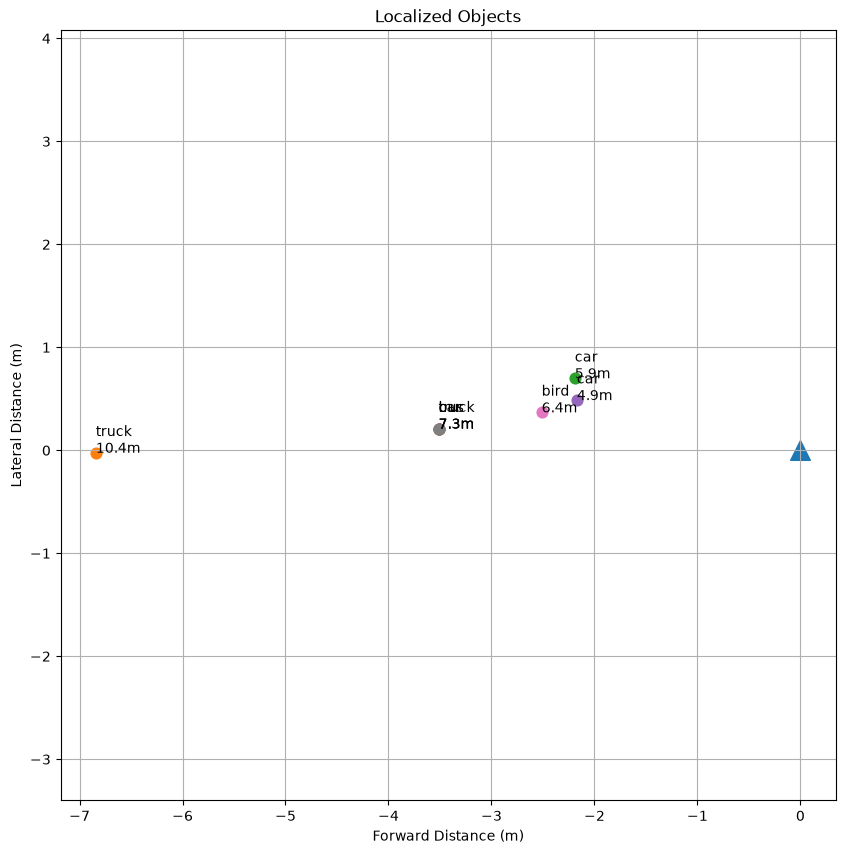

In [31]:
from visualization.localization_view import (
    visualize_localization,
    plot_localized_objects
)

visualize_localization(
    objects
)

plot_localized_objects(
    objects,
    save_path="../outputs/images/localization_result.png"
)